# Детекция объектов: интерактивные эксперименты

Детектор предлагает рамки и оценки уверенности, но между его выходом и числом
«найденных объектов» есть ещё несколько решений. В каждом стенде разберём одно
такое решение: **прочитайте цель → предположите результат → проверьте его
ползунками → назовите параметры и объясните наблюдение**.
На поиск ответов после разбора стенда отводим 2–3 минуты.
Модель в этом ноутбуке уже обучена; её веса во время опытов не меняются.

| Стенд | Основной вопрос |
|---|---|
| IoU | Когда визуально разумная рамка становится ошибкой? |
| Greedy NMS | Почему исчезают настоящие объекты и остаются ложные? |
| Score → precision/recall | Почему высокий score не равен TP? |
| Реальные изображения | Как разделить инференс, фильтрацию и оценку? |
| Пирамида изображений | Могут ли два размера входа найти больше объектов вместе? |

Сначала предположите ответ, затем двигайте ползунки. У соседа могут получиться
другие подходящие параметры: сравните их и найдите причину.
В каждом раунде есть небольшая таблица: впишите значения в Markdown или
назовите их вслух. Достаточно параметров и одного предложения с объяснением.

Откройте ноутбук в JupyterLab или загрузите в Colab и выполняйте сверху вниз.
Каждый стенд содержит обычный статический вызов: сохранённые изображения
доступны при просмотре на GitHub даже без работающих widgets.
Реализации вспомогательных функций в JupyterLab свёрнуты: их можно раскрыть слева от ячейки.
Все ячейки, включая свёрнутые, выполняются обычной командой Run All.

## Подготовка

Первые три стенда работают на CPU и не требуют скачивания данных или весов.
Четвёртый использует компактный YOLO11n и четыре изображения из train.
Пятый использует ту же модель и ещё один train-кадр в двух масштабах.
Все пять стендов работают и без GPU; скачивание требуется только для двух последних.
Ползунки обновляются после отпускания мыши, чтобы не перегружать интерфейс.
В локальном Jupyter нужны ipywidgets 8 и включённый JavaScript.
Если контролы не появились, пользуйтесь обычными вызовами `render_*` ниже.

In [ ]:
# Выполните до остальных ячеек. В Colab готовый PyTorch обычно уже установлен.
import importlib.metadata as meta
import subprocess
import sys

packages = ['ultralytics==8.4.102', 'numpy>=1.26,<3',
            'matplotlib>=3.8,<4', 'pandas>=2.1,<4', 'Pillow>=10,<13',
            'ipywidgets>=8.1,<9']
try:
    ready = meta.version('ultralytics') == '8.4.102'
    for package in ['numpy', 'matplotlib', 'pandas', 'Pillow', 'torch', 'torchvision', 'ipywidgets']:
        meta.version(package)
except meta.PackageNotFoundError:
    ready = False
if not ready:
    # Сохраняем уже установленную пару PyTorch/torchvision, включая CUDA-сборку.
    # Если есть только torch, resolver подберёт совместимую torchvision к этой версии.
    for package in ['torch', 'torchvision']:
        try:
            packages.append(package + '==' + meta.version(package))
        except meta.PackageNotFoundError:
            pass
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *packages])
try:
    from google.colab import output as colab_output
except ImportError:
    pass
else:
    colab_output.enable_custom_widget_manager()
print('Библиотеки готовы. Python:', sys.version.split()[0])

In [ ]:
from pathlib import Path
import os
import json
import time
import hashlib
import shutil
import urllib.request
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
from IPython.display import display
import torch
import ultralytics
from ultralytics import YOLO

# Можно явно написать DEVICE = 'cpu', если CUDA недоступна или выдаёт ошибку.
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
torch.set_num_threads(min(4, os.cpu_count() or 1))
# По умолчанию всё сохраняется рядом с ноутбуком, а в Colab — в /content.
ROOT = Path(os.environ.get('DETECTION_LAB_ROOT', 'detection_lab_data')).resolve()
ROOT.mkdir(parents=True, exist_ok=True)
print('Устройство:', DEVICE)
print('PyTorch:', torch.__version__, '| Ultralytics:', ultralytics.__version__)
if DEVICE != 'cpu':
    print(torch.cuda.get_device_name(0))

In [ ]:
# Widgets are optional: every stand below also has an ordinary static function call.
try:
    import ipywidgets as widgets
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'ipywidgets>=8.1,<9'])
    import ipywidgets as widgets
try:
    from google.colab import output as colab_output
    colab_output.enable_custom_widget_manager()
except ImportError:
    pass
from IPython.display import clear_output
print('ipywidgets:', widgets.__version__)

In [ ]:
def box_iou(a, b):
    """IoU двух рамок [x1, y1, x2, y2]; вырожденная рамка имеет IoU = 0."""
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    intersection_wh = np.maximum(0, np.minimum(a[2:], b[2:]) - np.maximum(a[:2], b[:2]))
    intersection = float(np.prod(intersection_wh))
    area_a = float(np.prod(np.maximum(0, a[2:] - a[:2])))
    area_b = float(np.prod(np.maximum(0, b[2:] - b[:2])))
    union = area_a + area_b - intersection
    return intersection / union if union > 0 else 0.0

In [ ]:
def match_boxes(pred_boxes, scores, gt_boxes, match_iou=0.5):
    """Учебный greedy matching одного класса, одного изображения.
    Идём по убыванию score, выбираем лучший ещё свободный GT с IoU >= match_iou.
    Возвращаем метки TP/FP в исходном порядке предсказаний и индексы пропущенных GT.
    """
    pred_boxes = np.asarray(pred_boxes, dtype=float).reshape(-1, 4)
    gt_boxes = np.asarray(gt_boxes, dtype=float).reshape(-1, 4)
    labels = np.full(len(pred_boxes), 'FP', dtype=object)
    free_gt = set(range(len(gt_boxes)))
    for i in np.argsort(-np.asarray(scores), kind='stable'):
        if not free_gt:
            break
        j = max(sorted(free_gt), key=lambda j: box_iou(pred_boxes[i], gt_boxes[j]))
        if box_iou(pred_boxes[i], gt_boxes[j]) >= match_iou:
            labels[i] = 'TP'
            free_gt.remove(j)
    return labels, sorted(free_gt)

def evaluate(subset, predictions, conf=0.4, match_iou=0.5):
    rows = []
    for item in subset:
        pred = predictions[item['name']]
        take = pred['scores'] >= conf
        labels, missed = match_boxes(pred['boxes'][take], pred['scores'][take],
                                    item['boxes'], match_iou)
        rows.append(dict(image=item['name'], TP=int(np.sum(labels == 'TP')),
                         FP=int(np.sum(labels == 'FP')), FN=len(missed)))
    per_image = pd.DataFrame(rows)
    tp, fp, fn = (int(per_image[k].sum()) for k in ['TP', 'FP', 'FN'])
    # Суммируем объекты по набору (micro), не усредняем метрики отдельных картинок.
    summary = dict(TP=tp, FP=fp, FN=fn,
                   precision=tp / (tp + fp) if tp + fp else 0.0,
                   recall=tp / (tp + fn) if tp + fn else 0.0,
                   F1=2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else 0.0)
    return summary, per_image

def show_item(item, prediction=None, conf=0.4, match_iou=0.5, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 6))
    with Image.open(item['path']) as im:
        ax.imshow(im.convert('RGB'))
    def draw(box, color, text, style='-'):
        x1, y1, x2, y2 = box
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                               color=color, linewidth=2, linestyle=style))
        ax.text(x1, max(10, y1-3), text, color='white', fontsize=9,
                bbox=dict(facecolor=color, alpha=0.8, pad=1))
    if prediction is None:
        for i, box in enumerate(item['boxes']):
            draw(box, 'royalblue', f'GT {i+1}', '--')
    else:
        take = prediction['scores'] >= conf
        boxes, scores = prediction['boxes'][take], prediction['scores'][take]
        labels, missed = match_boxes(boxes, scores, item['boxes'], match_iou)
        for i, box in enumerate(item['boxes']):
            draw(box, 'royalblue', 'FN' if i in missed else 'GT', '--')
        for box, score, label in zip(boxes, scores, labels):
            draw(box, 'forestgreen' if label == 'TP' else 'crimson', f'{label} {score:.2f}')
    ax.set_title(item['name'])
    ax.axis('off')
    return ax

In [ ]:
def draw_box(ax, box, color, label, linestyle='-', linewidth=2, alpha=1.0, label_xy=None):
    x1, y1, x2, y2 = np.asarray(box, dtype=float)
    ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                          edgecolor=color, linestyle=linestyle,
                          linewidth=linewidth, alpha=alpha))
    text_x, text_y = (x1+1, y1+5) if label_xy is None else label_xy
    ax.text(text_x, text_y, label, color=color, fontsize=9,
            bbox={'facecolor': 'white', 'alpha': 0.85, 'edgecolor': 'none', 'pad': 1})


def finish_figure(fig):
    fig.tight_layout()
    plt.show()
    plt.close(fig)  # callbacks do not accumulate open figures


def control_slider(value, minimum, maximum, step, description):
    return widgets.FloatSlider(value=value, min=minimum, max=maximum, step=step,
                               description=description, continuous_update=False,
                               style={'description_width': 'initial'},
                               layout=widgets.Layout(width='420px'))

## Стенд 1. Геометрия IoU и решение о совпадении

**Что пытаемся понять.** Насколько хорошо предсказанная рамка совпадает
с размеченным объектом? Может ли результат оценки измениться, если сама рамка
осталась на месте?

**Цель опыта:** отдельно исследовать геометрию рамок и правило, по которому
детекцию засчитывают. Здесь один объект одного класса и одно предсказание;
модель не используется, рамку задаёте вы.

Пусть $G$ — эталонная рамка (ground truth, GT), а $B$ — предсказанная.
Мера пересечения над объединением сравнивает площади:

$$\mathrm{IoU}(B,G)=\frac{|B\cap G|}{|B\cup G|}
=\frac{S_{\text{пересечения}}}
{S_B+S_G-S_{\text{пересечения}}}.$$

IoU равен 0 без пересечения и 1 при полном совпадении.
**IoU = 0.50 означает 50%, а не 50.** Для оценки вводим отдельный порог
$\tau_{\text{match}}$: совпадение засчитывается при
$\mathrm{IoU}(B,G)\geq\tau_{\text{match}}$.
TP — засчитанное предсказание, FP — незасчитанное предсказание,
FN — эталонный объект, которому не нашлось подходящего предсказания.

**Как читать стенд.** Синяя пунктирная рамка — неподвижный эталон
`(30, 30)–(100, 90)`, оранжевая — ваше предсказание, фиолетовая заливка —
пересечение. Ось $x$ направлена вправо, $y$ — вниз, как у изображения.
В таблице под рисунком показаны площади пересечения и объединения, IoU
и результат оценки TP/FP/FN.

**Чем управляем.** `x` и `y` задают левый верхний угол предсказания,
ширина и высота меняют его размер. `MATCH IoU` меняет только правило оценки.
Для каждого задания меняйте один указанный параметр и сравнивайте численный
IoU с порогом, прежде чем смотреть на TP/FP/FN.

In [ ]:
def iou_state(x=40, y=25, width=70, height=60, match_iou=0.5):
    """Pure geometry: one GT, one prediction, and the evaluation decision."""
    if width <= 0 or height <= 0:
        raise ValueError('Ширина и высота должны быть положительными.')
    if not 0 < match_iou <= 1:
        raise ValueError('Порог сопоставления должен быть в (0, 1].')
    gt = np.array([30, 30, 100, 90], dtype=float)
    prediction = np.array([x, y, x+width, y+height], dtype=float)
    overlap = box_iou(prediction, gt)
    lower = np.maximum(prediction[:2], gt[:2])
    upper = np.minimum(prediction[2:], gt[2:])
    intersection = float(np.prod(np.maximum(upper-lower, 0)))
    union = float(width*height + 70*60 - intersection)
    matched = overlap >= match_iou
    return dict(gt=gt, prediction=prediction, intersection=intersection, union=union,
                IoU=overlap, TP=int(matched), FP=int(not matched), FN=int(not matched))


def render_iou(x=40, y=25, width=70, height=60, match_iou=0.5):
    state = iou_state(x, y, width, height, match_iou)
    fig, ax = plt.subplots(figsize=(8, 5))
    draw_box(ax, state['gt'], 'royalblue', 'GT', '--', 3)
    draw_box(ax, state['prediction'], 'darkorange', 'Предсказание')
    lo = np.maximum(state['gt'][:2], state['prediction'][:2])
    hi = np.minimum(state['gt'][2:], state['prediction'][2:])
    if state['intersection'] > 0:
        ax.add_patch(Rectangle(lo, *(hi-lo), color='mediumpurple', alpha=0.2))
    ax.set(xlim=(0, 220), ylim=(180, 0), aspect='equal', xlabel='x, пиксели', ylabel='y, пиксели')
    ax.set_title(f"IoU = {state['IoU']:.3f}; match IoU ≥ {match_iou:.2f}; "
                 f"TP={state['TP']}, FP={state['FP']}, FN={state['FN']}")
    finish_figure(fig)
    display(pd.DataFrame([{key: state[key] for key in ['intersection', 'union', 'IoU', 'TP', 'FP', 'FN']}]))
    return state


def make_iou_widget():
    controls = {
        'x': control_slider(40, 0, 120, 1, 'Левый край x'),
        'y': control_slider(25, 0, 100, 1, 'Верхний край y'),
        'width': control_slider(70, 5, 100, 1, 'Ширина'),
        'height': control_slider(60, 5, 80, 1, 'Высота'),
        'match_iou': control_slider(0.5, 0.1, 1.0, 0.05, 'MATCH IoU'),
    }
    def update(**values):
        render_iou(**values)
    output = widgets.interactive_output(update, controls)
    return widgets.VBox([widgets.HBox([widgets.VBox(list(controls.values())[:3]),
                                      widgets.VBox(list(controls.values())[3:])]), output])

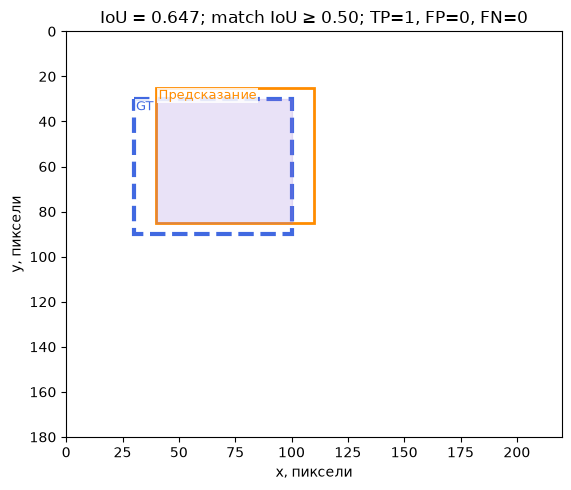

,intersection,union,IoU,TP,FP,FN
0,3300.0,5100.0,0.647059,1,0,0


In [ ]:
iou_example = render_iou(x=40, y=25, width=70, height=60, match_iou=0.5)

### Получите результат · 2–3 минуты

1. **IoU = 0.50.** Поставьте `x=30`, `y=30`, высоту `60` и `MATCH IoU=0.50`.
   Меняйте только ширину. Какой она должна быть? Засчиталась ли рамка как TP?
2. **IoU ≈ 0.333.** Верните ширину `70`, высоту `60`, `y=30`.
   Двигайте рамку только вправо от `x=30`. Найдите `x` с точностью IoU ±0.005.
   На какую долю ширины вы сдвинулись?
3. **Та же рамка: сначала TP=1, затем FP=1 и FN=1.** Сохраните геометрию
   из пункта 2. Найдите два соседних положения `MATCH IoU`, которые переключают
   результат. Что при этом случилось с самим IoU?

Если успели: получите IoU=0.50 ещё одним способом при `x=30`, `y=30`,
ширине `70`, меняя только высоту.

In [ ]:
iou_controls = make_iou_widget()
display(iou_controls)

| Цель | x, y, ширина, высота | MATCH IoU | Полученный IoU | TP / FP / FN |
|---|---|---|---|---|
| 0.50 изменением ширины | … | … | … | … |
| 0.333 сдвигом | … | … | … | … |
| Переключение TP → FP | те же | … → … | … → … | … → … |

**Обсудим:** почему одна предсказанная рамка может одновременно дать FP и FN?

## Стенд 2. Greedy NMS, шаг за шагом

**Что пытаемся понять.** Детектор может предложить несколько рамок для одного
объекта. Как убрать повторы, сохранив соседние объекты, если их рамки тоже
пересекаются?

**Цель опыта:** проследить каждое решение NMS и связать удаление конкретной
рамки с её score и пересечением. Координаты и score уже заданы и не меняются.
На сцене два эталонных объекта и четыре предсказания одного класса.

Greedy NMS (жадное подавление немаксимумов) повторяет три действия:

1. Выбирает из оставшихся предсказание $B_*$ с наибольшим score и сохраняет его.
2. Удаляет другие оставшиеся рамки $B_j$, для которых
   $\mathrm{IoU}(B_*,B_j)>\tau_{\text{NMS}}$.
3. Повторяет выбор, пока кандидаты не закончатся.

Здесь IoU сравнивает **два предсказания**. NMS не знает, сколько на сцене
объектов и где их эталонные рамки: он получает только рамки и score.
Проверку TP/FP/FN выполняем отдельно после завершения NMS, сравнивая
оставшиеся предсказания с разметкой при фиксированном `MATCH IoU=0.50`.

**Как читать стенд.** Синие пунктирные GT показывают настоящие объекты.
Номер возле предсказания позволяет найти его в таблице; рядом указан score.
Зелёный `keep` означает «сохранено», красный `suppress` — «удалено»,
оранжевый — «решение ещё не принято». Выбранная на текущем шаге рамка толще
остальных. Столбец `IoU_with_selected` показывает IoU каждой рамки с ней.

**Чем управляем.** «Шаг» показывает ход алгоритма: 0 — исходный набор,
каждый следующий шаг — один выбор и связанные с ним удаления.
`NMS IoU` задаёт допустимое пересечение: подавление происходит только при
**строгом превышении** этого порога. После смены порога начните с шага 0,
предположите следующее удаление и проверьте его. Цвет `keep` сам по себе
ещё не означает TP — итоговая оценка появится после последнего шага.

In [ ]:
NMS_GT = np.array([[15, 25, 75, 115], [55, 25, 115, 115]], dtype=float)
NMS_BOXES = np.array([[15, 25, 75, 115], [18, 27, 78, 117],
                      [55, 25, 115, 115], [135, 35, 170, 95]], dtype=float)
NMS_SCORES = np.array([0.95, 0.90, 0.80, 0.65])


def nms_trace(boxes, scores, nms_iou=0.5):
    """Return step 0 and each subsequent greedy NMS decision; GT is never an input."""
    boxes = np.asarray(boxes, dtype=float).reshape(-1, 4)
    scores = np.asarray(scores, dtype=float)
    if len(boxes) != len(scores) or not 0 <= nms_iou <= 1:
        raise ValueError('Проверьте длины массивов и порог NMS.')
    remaining = list(np.argsort(-scores, kind='stable'))
    keep, suppress = [], []
    trace = [dict(keep=[], suppress=[], remaining=remaining.copy(), selected=None, suppressed_now=[])]
    while remaining:
        selected = int(remaining.pop(0))
        keep.append(selected)
        suppressed_now = [int(j) for j in remaining if box_iou(boxes[selected], boxes[j]) > nms_iou]
        suppress.extend(suppressed_now)
        remaining = [j for j in remaining if j not in suppressed_now]
        trace.append(dict(keep=keep.copy(), suppress=suppress.copy(), remaining=remaining.copy(),
                          selected=selected, suppressed_now=suppressed_now))
    return trace


def render_nms(step=1, nms_iou=0.5):
    trace = nms_trace(NMS_BOXES, NMS_SCORES, nms_iou)
    actual_step = min(max(int(step), 0), len(trace)-1)
    state = trace[actual_step]
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, gt in enumerate(NMS_GT):
        draw_box(ax, gt, 'royalblue', f'GT {i}', '--', 3, 0.65,
                 label_xy=(gt[0], gt[3]+12))
    rows = []
    for i, (box, score) in enumerate(zip(NMS_BOXES, NMS_SCORES)):
        status = 'keep' if i in state['keep'] else 'suppress' if i in state['suppress'] else 'ожидает'
        color = {'keep': 'forestgreen', 'suppress': 'crimson', 'ожидает': 'darkorange'}[status]
        selected = i == state['selected']
        draw_box(ax, box, color, f'{i}: {score:.2f} {status}',
                 ':' if status == 'suppress' else '-', 4 if selected else 1.8,
                 0.4 if status == 'suppress' else 1.0,
                 label_xy=(box[0], box[1]-6-(10 if i == 1 else 0)))
        rows.append(dict(index=i, score=score, status=status,
                         IoU_with_selected=(box_iou(box, NMS_BOXES[state['selected']])
                                            if state['selected'] is not None else np.nan)))
    ax.set(xlim=(0, 195), ylim=(140, 0), aspect='equal')
    ax.set_title(f'Шаг {actual_step} из {len(trace)-1}; NMS IoU={nms_iou:.2f}; '
                 f"выбран {state['selected']}; подавлены сейчас {state['suppressed_now']}")
    finish_figure(fig)
    display(pd.DataFrame(rows).round(3))
    if int(step) > len(trace)-1:
        print('При этом пороге алгоритм уже завершился; показан последний шаг.')
    if not state['remaining']:
        kept = state['keep']
        labels, missed = match_boxes(NMS_BOXES[kept], NMS_SCORES[kept], NMS_GT, match_iou=0.5)
        print('Оценка результата отдельно от NMS, MATCH IoU=0.5:',
              'TP =', sum(labels == 'TP'), 'FP =', sum(labels == 'FP'), 'FN =', len(missed))
    return dict(step=actual_step, **state)


def make_nms_widget():
    controls = {
        'step': widgets.IntSlider(value=1, min=0, max=len(NMS_BOXES), description='Шаг',
                                  continuous_update=False),
        'nms_iou': control_slider(0.5, 0.0, 1.0, 0.05, 'NMS IoU'),
    }
    def update(**values):
        render_nms(**values)
    output = widgets.interactive_output(update, controls)
    return widgets.VBox([widgets.HBox(list(controls.values())), output])

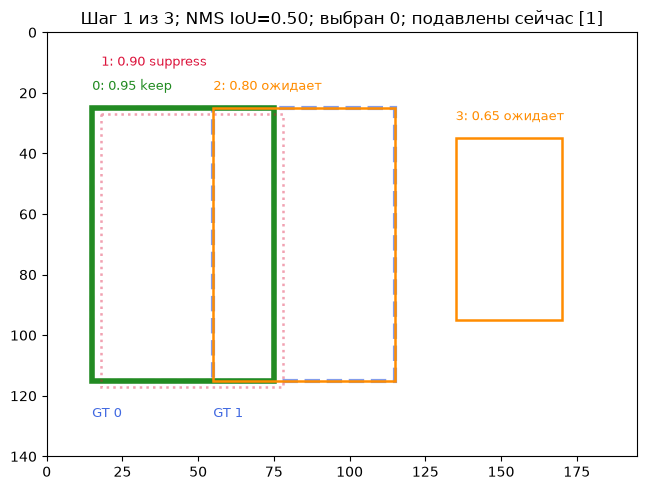

,index,score,status,IoU_with_selected
0,0,0.95,keep,1.000
1,1,0.90,suppress,0.867
2,2,0.80,ожидает,0.200
3,3,0.65,ожидает,0.000


In [ ]:
nms_example = render_nms(step=1, nms_iou=0.5)

### Получите результат · 2–3 минуты

1. **TP=2, FP=1, FN=0.** Найдите наименьший доступный `NMS IoU`, при котором
   после завершения остаются оба объекта и исчезает дубликат.
2. **TP=1, FP=1, FN=1.** Меняйте только порог NMS. Пройдите алгоритм по шагам:
   на каком шаге и из-за какой рамки исчезло нужное предсказание?
3. **Оставьте все четыре предсказания.** Найдите наименьший доступный порог.
   Сколько из оставшихся рамок являются TP?

Каждый раз доводите ползунок «Шаг» до конца. Если шагов стало меньше,
стенд сам покажет последний. Для одного из решений проверьте соседнее значение порога.

In [ ]:
nms_controls = make_nms_widget()
display(nms_controls)

| Цель | NMS IoU | Номера оставшихся рамок | TP / FP / FN |
|---|---|---|---|
| Два объекта, без дубликата | … | … | … |
| Один объект потерян | … | … | … |
| Все четыре предсказания | … | … | … |

**Обсудим:** почему одна ложная рамка пережила все три режима?
Какие сведения понадобились бы, чтобы отличить её от настоящего объекта?

## Стенд 3. Score, ранжирование и precision/recall

**Что пытаемся понять.** Какие предсказания стоит показывать пользователю?
Порог score позволяет убрать неуверенные ответы, но как при этом меняются
число найденных объектов и доля правильных ответов?

**Цель опыта:** научиться получать precision и recall из конкретных рамок,
а затем связывать эти числа с положением точки на графике.
В сцене три эталонных объекта и пять фиксированных предсказаний одного класса.
NMS здесь не применяется: все кандидаты доступны для исследования порога.

Score — оценка уверенности детектора. Она задаёт порядок предсказаний,
но сама по себе не подтверждает правильность рамки. Порог confidence $c$
оставляет предсказания со $s_i\geq c$. Для оставшихся рамок выполняем matching:
идём по убыванию score и ищем для каждой лучший ещё свободный GT с
$\mathrm{IoU}\geq\tau_{\text{match}}$. Один GT даёт не больше одного TP;
дубликат или рамка без подходящего GT даёт FP. Ненайденный GT даёт FN.

$$\mathrm{Precision}=\frac{TP}{TP+FP},\qquad
\mathrm{Recall}=\frac{TP}{TP+FN}=\frac{TP}{3}.$$

Precision отвечает «какая доля оставленных предсказаний верна?»,
recall — «какая доля эталонных объектов найдена?». Если предсказаний нет,
в этом стенде условно принимаем precision равным 0.

**Как читать три панели.** Слева — рамки: синий пунктир обозначает GT.
Цвет кандидата показывает его статус при включении в расчёт: зелёный — TP,
красный — FP. Отсеянные confidence рамки остаются бледными для сравнения,
но в текущие TP/FP не входят. В таблице `label` показывает статус кандидата,
а `selected` — включён ли он сейчас. В центре — те же предсказания
по убыванию score; горизонтальная линия показывает порог отбора.
Справа по горизонтали отложен recall, по вертикали — precision.
Серый узел с номером $k$ соответствует первым $k$ предсказаниям списка,
оранжевая звезда — вашему текущему порогу. Это точки для одного изображения;
площадь AP здесь не вычисляем.

**Чем управляем.** `Confidence` меняет число оставленных рамок,
`MATCH IoU` — требуемую точность их совпадения с GT. Геометрия и score
остаются прежними. Сначала по таблице определите, какие рамки войдут в расчёт,
посчитайте TP/FP/FN, затем проверьте положение звезды.

In [ ]:
PR_GT = np.array([[10, 20, 40, 80], [60, 20, 90, 80], [115, 20, 145, 80]], dtype=float)
PR_BOXES = np.array([[10, 20, 40, 80], [12, 20, 42, 80], [67, 20, 97, 80],
                     [115, 20, 145, 80], [160, 30, 185, 70]], dtype=float)
PR_SCORES = np.array([0.92, 0.86, 0.70, 0.55, 0.35])


def pr_state(conf=0.6, match_iou=0.5):
    """Ranked prefixes and one operating point, deliberately without AP integration."""
    if not 0 <= conf <= 1 or not 0 < match_iou <= 1:
        raise ValueError('Проверьте пороги.')
    order = np.argsort(-PR_SCORES, kind='stable')
    boxes, scores = PR_BOXES[order], PR_SCORES[order]
    labels, _ = match_boxes(boxes, scores, PR_GT, match_iou)
    tp_prefix = np.cumsum(labels == 'TP')
    fp_prefix = np.cumsum(labels == 'FP')
    precision = tp_prefix / np.arange(1, len(order)+1)
    recall = tp_prefix / len(PR_GT)
    selected_count = int(np.sum(scores >= conf))
    tp = int(tp_prefix[selected_count-1]) if selected_count else 0
    fp = selected_count-tp
    fn = len(PR_GT)-tp
    current = dict(TP=tp, FP=fp, FN=fn, precision=tp/selected_count if selected_count else 0.0,
                   recall=tp/len(PR_GT))
    ranked = pd.DataFrame(dict(rank=np.arange(1, len(order)+1), index=order, score=scores,
                              label=labels, selected=scores >= conf,
                              prefix_precision=precision, prefix_recall=recall))
    return dict(ranked=ranked, current=current, selected_count=selected_count,
                precision=precision, recall=recall, labels=labels, order=order)


def render_pr(conf=0.6, match_iou=0.5):
    state = pr_state(conf, match_iou)
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    for j, gt in enumerate(PR_GT):
        draw_box(axes[0], gt, 'royalblue', f'GT {j}', '--', 3, 0.6,
                 label_xy=(gt[0], gt[3]+10))
    for rank, i in enumerate(state['order']):
        color = 'forestgreen' if state['labels'][rank] == 'TP' else 'crimson'
        selected = PR_SCORES[i] >= conf
        draw_box(axes[0], PR_BOXES[i], color, f'{i}: {PR_SCORES[i]:.2f}',
                 '-' if selected else ':', 2, 1.0 if selected else 0.35,
                 label_xy=(PR_BOXES[i][0], PR_BOXES[i][1]-5-(9 if i == 1 else 0)))
    axes[0].set(xlim=(0, 200), ylim=(100, 0), aspect='equal', title='Рамки: TP / FP после matching')
    ranks = np.arange(1, len(PR_SCORES)+1)
    colors = ['forestgreen' if label == 'TP' else 'crimson' for label in state['labels']]
    axes[1].bar(ranks, PR_SCORES[state['order']], color=colors, alpha=0.75)
    axes[1].axhline(conf, color='black', linestyle='--', label=f'conf={conf:.2f}')
    axes[1].set(xlabel='Место в ранжировании', ylabel='Score', ylim=(0, 1.02), xticks=ranks,
                title='Какие предсказания остаются?')
    axes[1].legend()
    axes[2].plot(state['recall'], state['precision'], '-o', color='gray', label='Все непустые префиксы')
    for rank, (recall, precision) in enumerate(zip(state['recall'], state['precision']), 1):
        axes[2].annotate(str(rank), (recall, precision), xytext=(4, 5), textcoords='offset points')
    current = state['current']
    axes[2].scatter([current['recall']], [current['precision']], s=160, marker='*', color='darkorange',
                    label=f"При conf={conf:.2f} (оставлено {state['selected_count']})", zorder=5)
    axes[2].set(xlim=(-0.04, 1.08), ylim=(-0.04, 1.08), xlabel='Recall', ylabel='Precision',
                title=f'Эмпирические точки, MATCH IoU={match_iou:.2f}')
    axes[2].grid(alpha=0.3)
    axes[2].legend(loc='lower left', fontsize=8)
    finish_figure(fig)
    display(state['ranked'].round(3))
    display(pd.DataFrame([current]).round(3))
    if state['selected_count'] == 0:
        print('Нет предсказаний: здесь условно precision=0. Начальная точка AP может задаваться иначе.')
    return state


def make_pr_widget():
    controls = {
        'conf': control_slider(0.6, 0.0, 1.0, 0.01, 'Confidence'),
        'match_iou': control_slider(0.5, 0.1, 1.0, 0.05, 'MATCH IoU'),
    }
    def update(**values):
        render_pr(**values)
    output = widgets.interactive_output(update, controls)
    return widgets.VBox([widgets.HBox(list(controls.values())), output])

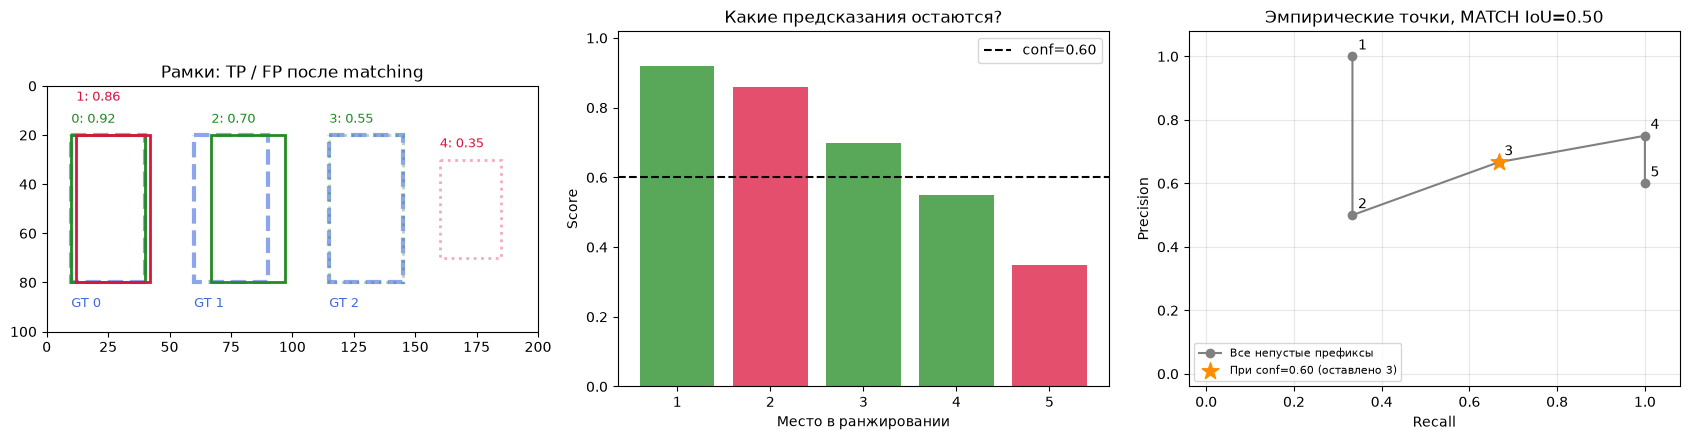

,rank,index,score,label,selected,prefix_precision,prefix_recall
0,1,0,0.92,TP,True,1.000,0.333
1,2,1,0.86,FP,True,0.500,0.333
2,3,2,0.70,TP,True,0.667,0.667
3,4,3,0.55,TP,False,0.750,1.000
4,5,4,0.35,FP,False,0.600,1.000


,TP,FP,FN,precision,recall
0,2,1,1,0.667,0.667


In [ ]:
pr_example = render_pr(conf=0.6, match_iou=0.5)

### Получите результат · 2–3 минуты

1. При `MATCH IoU=0.50` получите **precision=0.75 и recall=1.00**,
   меняя только confidence. Найдите ещё одно значение conf с тем же результатом.
2. Начните с `conf=0.80`, `MATCH IoU=0.50`. **Снизьте confidence так,
   чтобы precision вырос.** Назовите значения precision до и после и номера
   добавившихся рамок. За счёт чего получился рост?
3. Поставьте `conf=0.50`. Найдите наименьший доступный `MATCH IoU`, при котором
   **TP=2, FP=2, FN=1**. Какая рамка сменила статус? Изменилось ли её положение?

In [ ]:
pr_controls = make_pr_widget()
display(pr_controls)

| Цель | Confidence | MATCH IoU | Precision / recall | Что добавилось или сменило статус |
|---|---|---|---|---|
| 0.75 / 1.00 | … и … | 0.50 | … | … |
| Precision вырос при снижении conf | 0.80 → … | 0.50 | … → … | … |
| TP=2, FP=2, FN=1 | 0.50 | … | … | … |

**Обсудим:** получится ли получить одновременно precision=1 и recall=1
одним лишь confidence при `MATCH IoU=0.50`? Покажите, какая рамка помогает
или мешает этому, вместо перебора всех значений.

## Стенд 4. Реальные изображения: какие изменения требуют модели?

**Что пытаемся понять.** На фотографии после движения ползунка исчезла рамка.
Модель перестала видеть человека, фильтр скрыл готовый ответ или изменилось
только правило оценки?

**Цель опыта:** различать эти причины на выходе настоящего YOLO11n.
Рассматриваем только класс `person`. Модель уже обучена; её веса и фотография
во время сравнения остаются прежними.

В этом стенде результат проходит пять этапов:

| Этап | Что происходит | Что исследуем |
|---|---|---|
| Подготовка входа | Фотография масштабируется с сохранением пропорций и при необходимости дополняется полями | `imgsz` задаёт размер входа: человек занимает другое число пикселей |
| Инференс | Нейросеть вычисляет кандидаты: координаты рамок и score | При другом входе модель может выдать другие рамки и score |
| NMS | Перекрывающиеся предсказания сравниваются между собой, часть удаляется | `NMS IoU` управляет подавлением повторов |
| Фильтр confidence | Из готовых результатов остаются рамки со $s_i\geq c$ | `Confidence` скрывает ответы с меньшим score |
| Оценка по разметке | Оставшиеся рамки сопоставляются с GT при $\mathrm{IoU}\geq\tau_{\text{match}}$ | `MATCH IoU` определяет TP/FP/FN |

Перед NMS также действует технический нижний порог score `0.05`.
Ползунок confidence работает в пределах уже сохранённых результатов,
начиная с этого значения. Разметка используется только на последнем этапе,
она не поступает на вход детектору или NMS.

**Как читать результат.** Синяя пунктирная рамка — GT, подпись `FN` у неё
означает, что подходящее предсказание не найдено. Зелёные рамки — TP,
красные — FP; число в подписи — score. Под фотографией — TP/FP/FN,
precision, recall и F1. Все рамки показаны в координатах исходной фотографии:
её размер на экране не показывает, в каком разрешении работала сеть.

**Чем управляем.** Выберите фотографию и меняйте один параметр за раз.
`Confidence` и `MATCH IoU` обновляют картинку сразу. После смены фотографии,
`imgsz` или `NMS IoU` нажмите **«Пересчитать»**, если для этого сочетания
ещё нет результата. Перед нажатием назовите этап, который должен измениться,
и предположите, изменятся ли сами координаты рамок.

**Почему иногда пересчёт мгновенный.** Уже полученные предсказания сохраняются
в памяти (кэше). Возврат к той же фотографии, размеру входа и NMS IoU использует
готовый результат. Confidence и MATCH IoU всегда работают с этим результатом
без запуска сети. Для нового NMS IoU стенд повторяет вызов детектора:
сохранены рамки после NMS, а удалённые на прошлом запуске кандидаты недоступны.

### Данные и разбиение

Используем Penn–Fudan Pedestrian Database:
170 изображений, маски отдельных людей. В скачиваемом архиве 423 маски объектов;
код проверяет число объектов и превращает маски в рамки `xyxy`.
Рамки охватывают размеченные пиксели, то есть видимую часть человека; модель может
предсказывать более полную фигуру. Это иногда снижает IoU даже при разумной детекции.

**Разметка не покрывает всех видимых людей.** На некоторых кадрах дальние или сильно
перекрытые люди остаются без маски. Их обнаружение даст **FP относительно разметки**,
хотя человек на снимке действительно есть. При разборе отличайте ошибку модели от
неполноты эталона; после просмотра test не исправляйте разметку ради повышения метрики.

Фиксируем разбиение с `seed=42`: **120 train / 25 val / 25 test**.
`train` нужен для демонстрации, замера времени и дополнительного дообучения.
Настройки выбираем по `val`; к `test` обращаемся после выбора.
Это учебное разбиение по изображениям, не по независимым сценам: похожие сцены
могут оказаться в разных частях. Малый тест не оценивает работу на произвольном видео.
Во всех изображениях есть люди: ложные срабатывания на полностью пустых сценах
этим набором не проверяются.

Архив (~51 MiB) и веса (~5.4 MiB) загружаются без регистрации и API-ключей.
При повторном запуске используем локальные файлы, проверяя SHA-256.

В этом стенде используем только первые четыре изображения train. Val/test
остаются вне интерактивного исследования. Разбиение фиксируется общим кодом
для согласованности с остальными ноутбуками. Penn-Fudan содержит людей на
каждом изображении, поэтому здесь нет проверки ложных срабатываний на сценах
совсем без людей.

In [ ]:
def fetch_checked(url, target, expected_sha256):
    target = Path(target)
    def digest(p):
        h = hashlib.sha256()
        with p.open('rb') as f:
            for chunk in iter(lambda: f.read(1024 * 1024), b''):
                h.update(chunk)
        return h.hexdigest()
    if target.exists() and digest(target) == expected_sha256:
        return target
    temp = target.with_suffix(target.suffix + '.part')
    print('Загрузка:', target.name)
    try:
        request = urllib.request.Request(url, headers={'User-Agent': 'DetectionLab/1.0'})
        with urllib.request.urlopen(request, timeout=90) as source, temp.open('wb') as out:
            shutil.copyfileobj(source, out)
        if digest(temp) != expected_sha256:
            raise ValueError('Контрольная сумма не совпала: ' + target.name)
        temp.replace(target)
    except Exception as exc:
        temp.unlink(missing_ok=True)
        raise RuntimeError('Не удалось загрузить ' + target.name +
                           '. Проверьте интернет и повторите ячейку. '
                           'Можно вручную положить исходный файл в ' + str(ROOT)) from exc
    return target

archive = fetch_checked(
    'https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip',
    ROOT / 'PennFudanPed.zip',
    '9095a9613c95586f1c7f2a327d454833d16e0f5e17e5f83d35027ffd315b48e2')
DATA = ROOT / 'PennFudanPed'
if not (DATA / '.lab_extracted').exists():
    with zipfile.ZipFile(archive) as z:
        for member in z.infolist():
            if not (ROOT / member.filename).resolve().is_relative_to(ROOT):
                raise ValueError('Некорректный путь внутри архива')
        z.extractall(ROOT)
    (DATA / '.lab_extracted').touch()
WEIGHTS = fetch_checked(
    'https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11n.pt',
    ROOT / 'yolo11n.pt',
    '0ebbc80d4a7680d14987a577cd21342b65ecfd94632bd9a8da63ae6417644ee1')
print('Данные и веса готовы:', ROOT)

In [ ]:
# Эталонные рамки строим по маскам экземпляров: 0 — фон, каждый другой ID — человек.
def read_item(image_path):
    image_path = Path(image_path)
    mask_path = DATA / 'PedMasks' / (image_path.stem + '_mask.png')
    with Image.open(image_path) as im:
        width, height = im.size
    with Image.open(mask_path) as im:
        mask = np.array(im)
    boxes = []
    for instance_id in np.unique(mask):
        if instance_id == 0:
            continue
        ys, xs = np.where(mask == instance_id)
        # Полуоткрытые границы: правый/нижний край идут после последнего пикселя.
        boxes.append([xs.min(), ys.min(), xs.max() + 1, ys.max() + 1])
    return dict(path=image_path, name=image_path.name, width=width, height=height,
                boxes=np.asarray(boxes, dtype=float).reshape(-1, 4))

image_paths = sorted((DATA / 'PNGImages').glob('*.png'))
assert len(image_paths) == 170, 'Проверьте, полностью ли распакован PennFudanPed'
items = [read_item(p) for p in image_paths]
permutation = np.random.default_rng(42).permutation(len(items))
train_items = [items[i] for i in permutation[:120]]
val_items = [items[i] for i in permutation[120:145]]
test_items = [items[i] for i in permutation[145:]]
assert not ({x['name'] for x in train_items} & {x['name'] for x in val_items})
assert not ({x['name'] for x in test_items} & {x['name'] for x in train_items + val_items})
splits = {name: [x['name'] for x in subset] for name, subset in
          [('train', train_items), ('val', val_items), ('test', test_items)]}
(ROOT / 'split_seed42.json').write_text(json.dumps(splits, indent=2), encoding='utf-8')
print('Изображений: train =', len(train_items), 'val =', len(val_items), 'test =', len(test_items))
print('Всего эталонных объектов:', sum(len(x['boxes']) for x in items))
assert sum(len(x['boxes']) for x in items) == 423

In [ ]:
model = YOLO(str(WEIGHTS))
assert model.names[0] == 'person'
NMS_IOU = 0.5
MATCH_IOU = 0.5
LOW_CONF = 0.05  # Все исследуемые conf должны быть >= этого значения.

def predict_subset(subset, imgsz=640, nms_iou=NMS_IOU, detector=None):
    detector = model if detector is None else detector
    predictions = {}
    # По одному изображению: небольшой расход памяти и одинаковая процедура на CPU/GPU.
    for item in subset:
        result = detector.predict(str(item['path']), imgsz=imgsz, conf=LOW_CONF,
                                  iou=nms_iou, classes=[0], device=DEVICE,
                                  quantize=32, max_det=100, verbose=False)[0]
        predictions[item['name']] = {
            'boxes': result.boxes.xyxy.cpu().numpy().copy(),
            'scores': result.boxes.conf.cpu().numpy().copy(),
        }
    return predictions

def benchmark(item, imgsz, repeats=5):
    # Прогрев отдельно для каждого размера, замер всего predict из памяти:
    # preprocessing + inference + NMS, без чтения изображения и скачивания модели.
    with Image.open(item['path']) as im:
        array = np.array(im.convert('RGB'))[:, :, ::-1].copy()  # NumPy-вход YOLO: BGR
    def sync():
        if DEVICE.startswith('cuda'):
            torch.cuda.synchronize()
    def run():
        return model.predict(array, imgsz=imgsz, conf=LOW_CONF, iou=NMS_IOU,
                             classes=[0], device=DEVICE, quantize=32, max_det=100,
                             verbose=False)
    for _ in range(2):
        run()
    times = []
    for _ in range(repeats):
        sync()
        start = time.perf_counter()
        run()
        sync()
        times.append(1000 * (time.perf_counter() - start))
    return float(np.median(times))
print('Готова модель YOLO11n. Оцениваем только класс person.')

### Три разных порога

| Параметр | Что сравниваем | На что влияет |
|---|---|---|
| `conf` | score предсказания с порогом | Какие предсказания оставить |
| `NMS_IOU` | предсказание с предсказанием | Какие перекрывающиеся рамки удалить |
| `MATCH_IOU` | предсказание с эталонной рамкой | Считать ли оставшееся предсказание TP |

Одна эталонная рамка даёт максимум один TP. Лишняя рамка того же человека — FP.
Найденный человек с недостаточным IoU даёт FP и оставляет FN.
В этом ноутбуке один класс, поэтому сопоставляем рамки отдельно на каждом изображении.
В многоклассовой задаче дополнительно учитывают класс.

`precision = TP / (TP + FP)`, `recall = TP / (TP + FN)`.
При нулевом знаменателе здесь условно ставим 0. Результаты агрегируем по объектам.
Это precision/recall при фиксированном пороге, **не AP/mAP**. Для AP строят кривую
по ранжированным предсказаниям, для mAP усредняют AP по классам
(и по IoU-порогам, если это предусмотрено протоколом).
Учебный greedy matching здесь не является полной реализацией COCOeval с crowd/ignore.

In [ ]:
REAL_CACHE = {}
# The checkpoint digest identifies the model, not just its filename.
MODEL_FINGERPRINT = hashlib.sha256(Path(WEIGHTS).read_bytes()).hexdigest()
EXPLORER_ITEMS = train_items[:4]


def inference_config(imgsz=320, nms_iou=0.5):
    """Every inference argument used by this stand, except the source file."""
    return dict(imgsz=int(imgsz), conf=float(LOW_CONF), iou=round(float(nms_iou), 6),
                classes=[0], device=str(DEVICE), quantize=32, max_det=100,
                augment=False, agnostic_nms=False, rect=True, batch=1,
                verbose=False, save=False, stream=False)


def prediction_cache_key(item, imgsz=320, nms_iou=0.5, model_key=None):
    # Exact image bytes and model checkpoint identity prevent reuse for changed inputs.
    image_digest = hashlib.sha256(Path(item['path']).read_bytes()).hexdigest()
    parameters = dict(source=str(Path(item['path']).resolve()), image_sha256=image_digest,
                      model_sha256=MODEL_FINGERPRINT if model_key is None else str(model_key),
                      ultralytics_version=ultralytics.__version__,
                      predict=inference_config(imgsz, nms_iou))
    return json.dumps(parameters, sort_keys=True, ensure_ascii=True), parameters


def cache_get_prediction(item, imgsz=320, nms_iou=0.5, detector=None, cache=None, model_key=None):
    """Only this function runs inference; the widget calls it only on button click.
    Tests may pass a fake detector, an empty cache, and an explicit model_key.
    """
    detector = model if detector is None else detector
    if detector is not model and model_key is None:
        raise ValueError('Для другой модели передайте model_key, чтобы разделить кэши.')
    cache = REAL_CACHE if cache is None else cache
    key, parameters = prediction_cache_key(item, imgsz, nms_iou, model_key)
    if key in cache:
        return cache[key], True
    start = time.perf_counter()
    result = detector.predict(str(item['path']), **parameters['predict'])[0]
    record = dict(prediction={
        'boxes': result.boxes.xyxy.cpu().numpy().copy(),
        'scores': result.boxes.conf.cpu().numpy().copy(),
    }, parameters=parameters, seconds=time.perf_counter()-start)
    cache[key] = record
    return record, False


def render_real(item, prediction, conf=0.4, match_iou=0.5, parameters=None):
    """Draw and evaluate existing predictions; no model calls or downloads."""
    if conf < LOW_CONF:
        raise ValueError(f'Кэш содержит предсказания только со score ≥ {LOW_CONF}.')
    summary, _ = evaluate([item], {item['name']: prediction}, conf=conf, match_iou=match_iou)
    fig, ax = plt.subplots(figsize=(11, 6))
    show_item(item, prediction, conf=conf, match_iou=match_iou, ax=ax)
    finish_figure(fig)
    display(pd.DataFrame([summary]).round(3))
    if parameters is not None:
        config = parameters['predict']
        print(f"Кэш: imgsz={config['imgsz']}, NMS IoU={config['iou']}, "
              f"минимальный score={config['conf']}; сейчас conf={conf:.2f}, MATCH IoU={match_iou:.2f}.")
    return summary


def render_real_cached(image_index=0, imgsz=320, nms_iou=0.5, conf=0.4, match_iou=0.5):
    """Look up the exact cache key and render; never start inference implicitly."""
    item = EXPLORER_ITEMS[int(image_index)]
    key, parameters = prediction_cache_key(item, imgsz, nms_iou)
    if key not in REAL_CACHE:
        print('Для выбранного изображения, imgsz и NMS IoU ещё нет предсказаний. '
              'Нажмите «Пересчитать». Изменение confidence/MATCH IoU не запускает модель.')
        return None
    return render_real(item, REAL_CACHE[key]['prediction'], conf, match_iou, parameters)


def make_real_widget():
    image_select = widgets.Dropdown(options=[(item['name'], i) for i, item in enumerate(EXPLORER_ITEMS)],
                                    value=0, description='Изображение:',
                                    style={'description_width': 'initial'}, layout=widgets.Layout(width='420px'))
    imgsz_select = widgets.Dropdown(options=[320, 480, 640], value=320, description='imgsz:')
    nms_control = control_slider(0.5, 0.1, 0.9, 0.05, 'NMS IoU')
    conf_control = control_slider(0.4, LOW_CONF, 0.95, 0.05, 'Confidence')
    match_control = control_slider(0.5, 0.1, 1.0, 0.05, 'MATCH IoU')
    button = widgets.Button(description='Пересчитать', icon='refresh', button_style='primary')
    output = widgets.Output()
    def refresh(change=None):
        with output:
            clear_output(wait=True)
            render_real_cached(image_select.value, imgsz_select.value, nms_control.value,
                               conf_control.value, match_control.value)
    def recompute(clicked):
        button.disabled = True
        try:
            with output:
                clear_output(wait=True)
                item = EXPLORER_ITEMS[image_select.value]
                print('Подготовка предсказаний для', item['name'])
                _, from_cache = cache_get_prediction(item, imgsz_select.value, nms_control.value)
                print('Найден точный кэш.' if from_cache else 'Модель выполнена; результат добавлен в кэш.')
                render_real_cached(image_select.value, imgsz_select.value, nms_control.value,
                                   conf_control.value, match_control.value)
        except Exception as exc:
            with output:
                print(type(exc).__name__ + ': ' + str(exc))
                print('Можно уменьшить imgsz или выбрать DEVICE="cpu" в ячейке окружения.')
        finally:
            button.disabled = False
    for control in [image_select, imgsz_select, nms_control, conf_control, match_control]:
        control.observe(refresh, names='value')
    button.on_click(recompute)
    refresh()
    return widgets.VBox([
        widgets.HBox([image_select, imgsz_select]),
        widgets.HBox([nms_control, button]),
        widgets.HBox([conf_control, match_control]), output,
    ])

PennPed00080.png инференс 1.43 с
FudanPed00055.png инференс 0.09 с
FudanPed00008.png инференс 0.07 с


FudanPed00034.png инференс 0.05 с


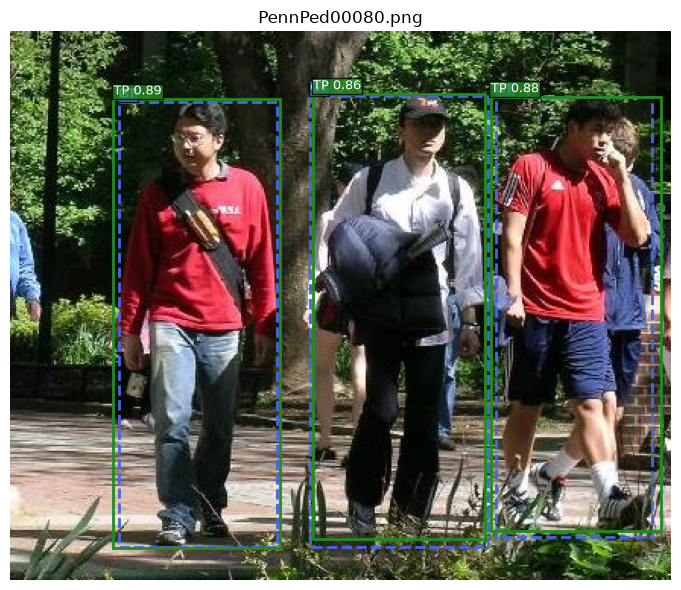

,TP,FP,FN,precision,recall,F1
0,3,0,0,1.0,1.0,1.0


Кэш: imgsz=320, NMS IoU=0.5, минимальный score=0.05; сейчас conf=0.40, MATCH IoU=0.50.


In [ ]:
# Явная одноразовая подготовка четырёх train-примеров; без фоновых вычислений.
for item in EXPLORER_ITEMS:
    record, was_cached = cache_get_prediction(item, imgsz=320, nms_iou=0.5)
    print(item['name'], 'из кэша' if was_cached else f"инференс {record['seconds']:.2f} с")
real_example = render_real_cached(image_index=0, imgsz=320, nms_iou=0.5,
                                  conf=0.4, match_iou=0.5)

### Получите результат · 2–3 минуты

Выберите **FudanPed00008.png**; начальные настройки: `imgsz=320`,
`NMS IoU=0.50`, `conf=0.40`, `MATCH IoU=0.50`.

1. **FP=0 и FN=0.** Меняйте только confidence. Какое значение подошло?
   Какая рамка исчезла? У соседа получился такой же порог или другой?
2. Верните `conf=0.40`. **TP=1, FP=2, FN=1.** Меняйте только `MATCH IoU`.
   Покажите рамку, которая сменила статус, и сравните её с эталоном.
3. Верните `MATCH IoU=0.50`. **Получите две версии детекций одного кадра —
   при imgsz=320 и imgsz=640.** Остальные параметры оставьте неизменными.
   Сначала предположите, что изменится, затем нажмите «Пересчитать».
   Найдите хотя бы одно различие в координатах, score или количестве рамок.
   Вернитесь к `320`: понадобился ли ещё один запуск модели?

Если точная цель в пунктах 1–2 не получилась, запишите ближайший результат
и его параметры: небольшие численные различия между CPU и GPU тоже можно обсудить.
Для сравнения используйте одну и ту же картинку.

In [ ]:
real_controls = make_real_widget()
display(real_controls)

| Цель | conf | MATCH IoU | imgsz | TP / FP / FN | Наблюдение |
|---|---|---|---|---|---|
| FP=0, FN=0 | … | 0.50 | 320 | … | … |
| TP=1, FP=2, FN=1 | 0.40 | … | 320 | … | … |
| Другой размер входа | 0.40 | 0.50 | 320 → 640 | … → … | … |

**Обсудим:** какое действие изменило выход модели, какое лишь отфильтровало
готовые рамки, а какое изменило правила оценки? Изменилось ли при этом число
людей на самой фотографии?

## Стенд 5. Пирамида изображений: разные масштабы дополняют друг друга

**Что пытаемся понять.** Если увеличить входное изображение, станут ли лучше
видны все объекты сразу? Или один размер помогает одному человеку, а другой —
другому?

**Цель опыта:** найти на одном снимке два противоположных случая, а затем
объединить результаты так, чтобы сохранить обоих людей без дубликатов.
Используем настоящие предсказания одной YOLO11n при `imgsz=256` и `imgsz=1280`.
Веса, исходная фотография, порог confidence и правила оценки одинаковы.

### Почему масштаб может изменить результат

На исходном снимке один человек занимает много пикселей, другой — мало.
При уменьшении входа меняются детали, доступные сети, и размер объекта
относительно её карт признаков. Увеличение входа тоже не гарантирует более
высокий score: детектор не обладает точной инвариантностью к масштабу.
Новых деталей в исходной фотографии от увеличения не появляется.
Мы проверяем конкретный эффект на выходе модели; по одному примеру нельзя
определить, какой внутренний слой стал причиной изменения.

Для исходного размера $W\times H$ и целевой длинной стороны $L$ коэффициент
масштабирования равен

$$r_L=\min\left(\frac{L}{W},\frac{L}{H}\right).$$

После изменения размера добавляются поля (letterbox), чтобы размеры входа
были кратны шагу сети. Значение `imgsz` задаёт целевую длинную сторону,
а не произвольную пару высоты и ширины. В этом почти квадратном кадре поля
доводят входы до $256\times256$ и $1280\times1280$; для вытянутой фотографии
они могли бы быть прямоугольными. Размеры показаны над панелями и в таблице.
Если поле слева равно $p_x$, то координата меняется как

$$x_L=r_L x+p_x,\qquad x=\frac{x_L-p_x}{r_L};$$

аналогично для $y$. Чтобы сравнить и объединить рамки разных масштабов,
их нужно вернуть к общей системе координат исходного снимка.
`result.boxes.xyxy` уже содержит такие координаты: библиотека выполнила
обратное преобразование. Дополнительно масштабировать их в этом коде не нужно.

### Как устроена пирамида

Одна фотография проходит через детектор дважды — с разными размерами входа.
Результаты фильтруются общим confidence, объединяются, затем NMS удаляет
повторы между масштабами:

$$\mathcal D_{\text{pyramid}}=
\operatorname{NMS}_{\tau_{\text{merge}}}
\left(\mathcal D_{256}^{\text{orig}}\cup
\mathcal D_{1280}^{\text{orig}}\right).$$

Здесь $\mathcal D_L^{\text{orig}}$ — рамки и score одного запуска в исходных
координатах, уже после внутреннего NMS и фильтра confidence.
Это пирамида **входных изображений**: для двух размеров нужны два прохода сети.
Внутренняя пирамида признаков сети строится в рамках одного прохода и является
отдельным механизмом.

**Как читать четыре панели.** Сверху слева — исходный кадр с двумя эталонными
людьми: A / GT 1 на переднем плане, B / GT 2 вдали. Сверху справа — меньший
вход, снизу слева — больший, снизу справа — объединение. Во всех панелях
фотография показана в одном экранном размере для удобства сравнения.
Зелёная рамка — TP, оранжевый пунктир — пропущенный GT (FN), красная — FP.
В объединении число в квадратных скобках указывает, из какого масштаба пришла рамка.

**Чем управляем.** `Confidence` общий для обоих запусков. Флажки включают
масштабы в объединение; две отдельные панели остаются видимыми для сравнения.
«NMS после объединения» убирает повторы, его ползунок меняет порог подавления.
Внутренний NMS каждой ветви и `MATCH IoU` зафиксированы на 0.50.
Ползунки используют готовые предсказания — повторно запускать сеть не требуется.

In [ ]:
PYRAMID_IMAGE_NAME = 'PennPed00061.png'
PYRAMID_SIZES = (256, 1280)
PYRAMID_CONF = 0.66
PYRAMID_HIGHLIGHT_GT = (1, 2)  # Номера GT на рисунке: объект A и объект B.
PYRAMID_MATCH_IOU = 0.50
PYRAMID_BRANCH_NMS = 0.50


def pyramid_input_shape(item, imgsz, stride=32):
    """H×W после letterbox для YOLO11n: rect=True, одно изображение за вызов."""
    side = int(np.ceil(int(imgsz) / stride) * stride)
    ratio = min(side / item['height'], side / item['width'])
    resized_width = round(item['width'] * ratio)
    resized_height = round(item['height'] * ratio)
    pad_width = (side - resized_width) % stride
    pad_height = (side - resized_height) % stride
    return dict(height=resized_height + pad_height, width=resized_width + pad_width,
                resized_height=resized_height, resized_width=resized_width,
                ratio=ratio, pad_height=pad_height, pad_width=pad_width)


def pyramid_cached_bundle(image_name=PYRAMID_IMAGE_NAME, sizes=PYRAMID_SIZES):
    """Только точный кэш. Эта функция никогда не запускает модель."""
    if len(sizes) != 2 or sizes[0] >= sizes[1] or min(sizes) <= 0:
        raise ValueError('Нужны два положительных размера: меньший, затем больший.')
    item = next((item for item in train_items if item['name'] == image_name), None)
    if item is None:
        raise ValueError('Изображение стенда должно находиться в train_items: ' + image_name)
    records = {}
    for size in sizes:
        key, _ = prediction_cache_key(item, size, PYRAMID_BRANCH_NMS)
        if key not in REAL_CACHE:
            return None
        records[int(size)] = REAL_CACHE[key]
    return dict(item=item, sizes=tuple(map(int, sizes)), records=records,
                network_shapes={int(size): pyramid_input_shape(item, size) for size in sizes})


def prepare_pyramid(image_name=PYRAMID_IMAGE_NAME, sizes=PYRAMID_SIZES):
    """Явная подготовка двух ветвей; повторный вызов использует точный кэш."""
    if len(sizes) != 2 or sizes[0] >= sizes[1] or min(sizes) <= 0:
        raise ValueError('Нужны два положительных размера: меньший, затем больший.')
    item = next((item for item in train_items if item['name'] == image_name), None)
    if item is None:
        raise ValueError('Изображение стенда должно находиться в train_items: ' + image_name)
    for size in sizes:
        record, from_cache = cache_get_prediction(item, size, PYRAMID_BRANCH_NMS)
        print(f'imgsz={size}: ' + ('точный кэш' if from_cache else 'модель выполнена') +
              f", сохранено {len(record['prediction']['scores'])} предсказаний.")
    return pyramid_cached_bundle(image_name, sizes)


def pyramid_matching(prediction, gt_boxes, match_iou=PYRAMID_MATCH_IOU):
    """Сопоставление один-к-одному; каждому предсказанию соответствует GT или −1."""
    boxes = np.asarray(prediction['boxes'], dtype=float).reshape(-1, 4)
    scores = np.asarray(prediction['scores'], dtype=float)
    gt_boxes = np.asarray(gt_boxes, dtype=float).reshape(-1, 4)
    if len(boxes) != len(scores):
        raise ValueError('Число рамок и оценок уверенности должно совпадать.')
    matches = np.full(len(boxes), -1, dtype=int)
    free_gt = set(range(len(gt_boxes)))
    for i in np.argsort(-scores, kind='stable'):
        if not free_gt:
            break
        j = max(sorted(free_gt), key=lambda j: box_iou(boxes[i], gt_boxes[j]))
        if box_iou(boxes[i], gt_boxes[j]) >= match_iou:
            matches[i] = j
            free_gt.remove(j)
    return matches, sorted(free_gt)


def pyramid_state(prepared, conf=PYRAMID_CONF, merge_nms=0.50,
                  use_small=True, use_large=True, cross_nms=True):
    """Фильтрация, объединение и оценка готовых результатов: без inference."""
    if not LOW_CONF <= conf <= 1 or not 0 <= merge_nms <= 1:
        raise ValueError(f'Confidence должен быть в [{LOW_CONF}, 1], NMS IoU — в [0, 1].')
    item, sizes = prepared['item'], prepared['sizes']
    predictions = {}
    for size in sizes:
        raw = prepared['records'][size]['prediction']
        keep = np.flatnonzero(np.asarray(raw['scores']) >= conf)
        predictions[size] = dict(
            boxes=np.asarray(raw['boxes'], dtype=float).reshape(-1, 4)[keep].copy(),
            scores=np.asarray(raw['scores'], dtype=float)[keep].copy(),
            source_size=np.full(len(keep), size, dtype=int),
            source_index=keep.copy())
    selected_sizes = [size for size, enabled in zip(sizes, [use_small, use_large]) if enabled]
    # Ultralytics уже вернул xyxy в координатах исходного изображения.
    # Повторно умножать или делить координаты на масштаб здесь нельзя.
    combined = {
        key: (np.concatenate([predictions[size][key] for size in selected_sizes], axis=0)
              if selected_sizes else np.empty((0, 4) if key == 'boxes' else (0,),
                                               dtype=float if key in ('boxes', 'scores') else int))
        for key in ['boxes', 'scores', 'source_size', 'source_index']
    }
    if cross_nms:
        trace = nms_trace(combined['boxes'], combined['scores'], merge_nms)
        kept = np.asarray(trace[-1]['keep'], dtype=int)
    else:
        kept = np.arange(len(combined['scores']), dtype=int)
    merged = {key: values[kept].copy() for key, values in combined.items()}
    predictions['pyramid'] = merged
    matches, missed, summary_rows = {}, {}, []
    for key, prediction in predictions.items():
        matches[key], missed[key] = pyramid_matching(prediction, item['boxes'])
        tp = int(np.sum(matches[key] >= 0))
        branch_sizes = selected_sizes if key == 'pyramid' else [key]
        shapes = [prepared['network_shapes'][size] for size in branch_sizes]
        dimensions = ' + '.join(f"{shape['height']}×{shape['width']}" for shape in shapes) or '—'
        summary_rows.append(dict(
            Вариант='Пирамида' if key == 'pyramid' else f'imgsz={key}',
            TP=tp, FP=int(len(prediction['scores']) - tp), FN=len(missed[key]),
            Recall=tp / len(item['boxes']) if len(item['boxes']) else 0.0,
            **{'Вход H×W': dimensions,
               'Пикселей на входе': sum(shape['height'] * shape['width'] for shape in shapes),
               'Сохранённое время, с': sum(prepared['records'][size]['seconds'] for size in branch_sizes)}))
    object_rows = []
    for gt_index in range(len(item['boxes'])):
        name = f'GT {gt_index + 1}'
        if gt_index + 1 in PYRAMID_HIGHLIGHT_GT:
            name += ' / ' + ('A' if gt_index + 1 == PYRAMID_HIGHLIGHT_GT[0] else 'B')
        row = {'Объект': name}
        for key, prediction in predictions.items():
            matched_indices = np.flatnonzero(matches[key] == gt_index)
            column = ('Пирамида: score / статус' if key == 'pyramid'
                      else f'imgsz={key}: score до conf / статус')
            if key != 'pyramid':
                raw = prepared['records'][key]['prediction']
                candidates = [float(score) for box, score in zip(raw['boxes'], raw['scores'])
                              if box_iou(box, item['boxes'][gt_index]) >= PYRAMID_MATCH_IOU]
                score_text = (f'{max(candidates):.3f}' if candidates else
                              f'<{LOW_CONF:.2f} или IoU<{PYRAMID_MATCH_IOU:.2f}')
                row[column] = score_text + (' / TP' if len(matched_indices) else ' / FN')
            elif len(matched_indices):
                index = int(matched_indices[0])
                row[column] = f"{prediction['scores'][index]:.3f} / TP"
                if key == 'pyramid':
                    row['Масштаб в пирамиде'] = int(prediction['source_size'][index])
            else:
                row[column] = '— / FN'
                if key == 'pyramid':
                    row['Масштаб в пирамиде'] = '—'
        object_rows.append(row)
    return dict(item=item, sizes=sizes, predictions=predictions, merged=merged,
                combined=combined, kept=kept,
                suppressed_count=len(combined['scores']) - len(kept),
                matches=matches, missed=missed, selected_sizes=selected_sizes,
                summary=pd.DataFrame(summary_rows), objects=pd.DataFrame(object_rows))


def render_pyramid(conf=PYRAMID_CONF, merge_nms=0.50, use_small=True,
                   use_large=True, cross_nms=True, prepared=None):
    """Рисует готовые предсказания. Ползунки не запускают модель."""
    prepared = pyramid_cached_bundle() if prepared is None else prepared
    if prepared is None:
        print('Сначала выполните prepare_pyramid() или нажмите «Подготовить 2 масштаба».')
        return None
    state = pyramid_state(prepared, conf, merge_nms, use_small, use_large, cross_nms)
    item = state['item']
    with Image.open(item['path']) as source:
        pixels = np.array(source.convert('RGB'))
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    for ax in axes.flat:
        ax.imshow(pixels)
        ax.axis('off')
    for index, box in enumerate(item['boxes'], 1):
        label = f'GT {index}'
        if index in PYRAMID_HIGHLIGHT_GT:
            label += ' / ' + ('A' if index == PYRAMID_HIGHLIGHT_GT[0] else 'B')
        draw_box(axes[0, 0], box, 'royalblue', label, '--', 2.5)
    axes[0, 0].set_title(f"Исходный кадр и GT · {item['width']}×{item['height']} пикс.", fontsize=12)
    for ax, key in zip([axes[0, 1], axes[1, 0], axes[1, 1]], [*state['sizes'], 'pyramid']):
        prediction = state['predictions'][key]
        for gt_index in state['missed'][key]:
            draw_box(ax, item['boxes'][gt_index], 'darkorange', f'FN: GT {gt_index + 1}', '--', 2)
        for index, (box, score) in enumerate(zip(prediction['boxes'], prediction['scores'])):
            gt_index = state['matches'][key][index]
            label = f'GT {gt_index + 1}: {score:.2f}' if gt_index >= 0 else f'FP: {score:.2f}'
            if key == 'pyramid':
                label += f" [{prediction['source_size'][index]}]"
            draw_box(ax, box, 'forestgreen' if gt_index >= 0 else 'crimson', label)
        tp = int(np.sum(state['matches'][key] >= 0))
        fp, fn = len(prediction['scores']) - tp, len(state['missed'][key])
        if key == 'pyramid':
            title = 'Пирамида: ' + (' + '.join(map(str, state['selected_sizes'])) or 'ветви выключены')
            title += ' · ' + (f'NMS={merge_nms:.2f}' if cross_nms else 'без NMS объединения')
        else:
            shape = prepared['network_shapes'][key]
            title = f"imgsz={key} · вход {shape['height']}×{shape['width']}"
        ax.set_title(f'{title}\nTP={tp}, FP={fp}, FN={fn}', fontsize=12)
    fig.suptitle(f"{item['name']} · confidence ≥ {conf:.2f} · MATCH IoU ≥ {PYRAMID_MATCH_IOU:.2f}",
                 fontsize=14)
    finish_figure(fig)
    display(state['objects'])
    display(state['summary'].round({'Recall': 3, 'Сохранённое время, с': 3}))
    print('Зелёный — TP; красный — FP; оранжевый пунктир — пропущенный GT. '
          'Число в квадратных скобках — imgsz ветви, из которой пришла рамка.')
    print('В столбцах отдельных масштабов score до conf — максимум среди сохранённых '
          f'кандидатов с IoU ≥ {PYRAMID_MATCH_IOU:.2f} с этим GT, до текущего confidence. '
          'TP/FN определяется отдельно сопоставлением один-к-одному: даже подходящий кандидат '
          'не даёт TP двум объектам. В столбце пирамиды score принадлежит фактически оставленной '
          'и сопоставленной рамке. FN означает отсутствие подходящей свободной рамки после фильтрации.')
    print(f"После объединения подавлено рамок: {state['suppressed_count']}. "
          'NMS видит только рамки и score; GT используется отдельно для оценки.')
    print('Вход H×W учитывает letterbox и stride=32; на рисунках все рамки показаны '
          'на исходном кадре. Время — сохранённая длительность вызовов predict, '
          'для пирамиды их сумма; это наблюдение одного запуска, не замер скорости модели.')
    return state


def make_pyramid_widget():
    controls = {
        'conf': control_slider(PYRAMID_CONF, max(0.05, LOW_CONF), 0.95, 0.01, 'Confidence'),
        'merge_nms': control_slider(0.50, 0.10, 0.90, 0.05, 'NMS после объединения'),
        'use_small': widgets.Checkbox(value=True, description=f'Включить imgsz={PYRAMID_SIZES[0]}'),
        'use_large': widgets.Checkbox(value=True, description=f'Включить imgsz={PYRAMID_SIZES[1]}'),
        'cross_nms': widgets.Checkbox(value=True, description='NMS после объединения'),
    }
    button = widgets.Button(description='Подготовить 2 масштаба', icon='refresh',
                            button_style='primary', layout=widgets.Layout(width='240px'))
    output = widgets.Output()
    def refresh(change=None):
        with output:
            clear_output(wait=True)
            render_pyramid(**{name: control.value for name, control in controls.items()})
    def prepare(clicked):
        button.disabled = True
        try:
            with output:
                clear_output(wait=True)
                prepare_pyramid()
                render_pyramid(**{name: control.value for name, control in controls.items()})
        except Exception as exc:
            with output:
                print(type(exc).__name__ + ': ' + str(exc))
                print('Проверьте подготовку данных и модели в предыдущих ячейках.')
        finally:
            button.disabled = False
    for control in controls.values():
        control.observe(refresh, names='value')
    button.on_click(prepare)
    refresh()
    return widgets.VBox([
        widgets.HBox([controls['conf'], controls['merge_nms']]),
        widgets.HBox([controls['use_small'], controls['use_large'], controls['cross_nms']]),
        button, output,
    ])

imgsz=256: модель выполнена, сохранено 5 предсказаний.


imgsz=1280: модель выполнена, сохранено 12 предсказаний.


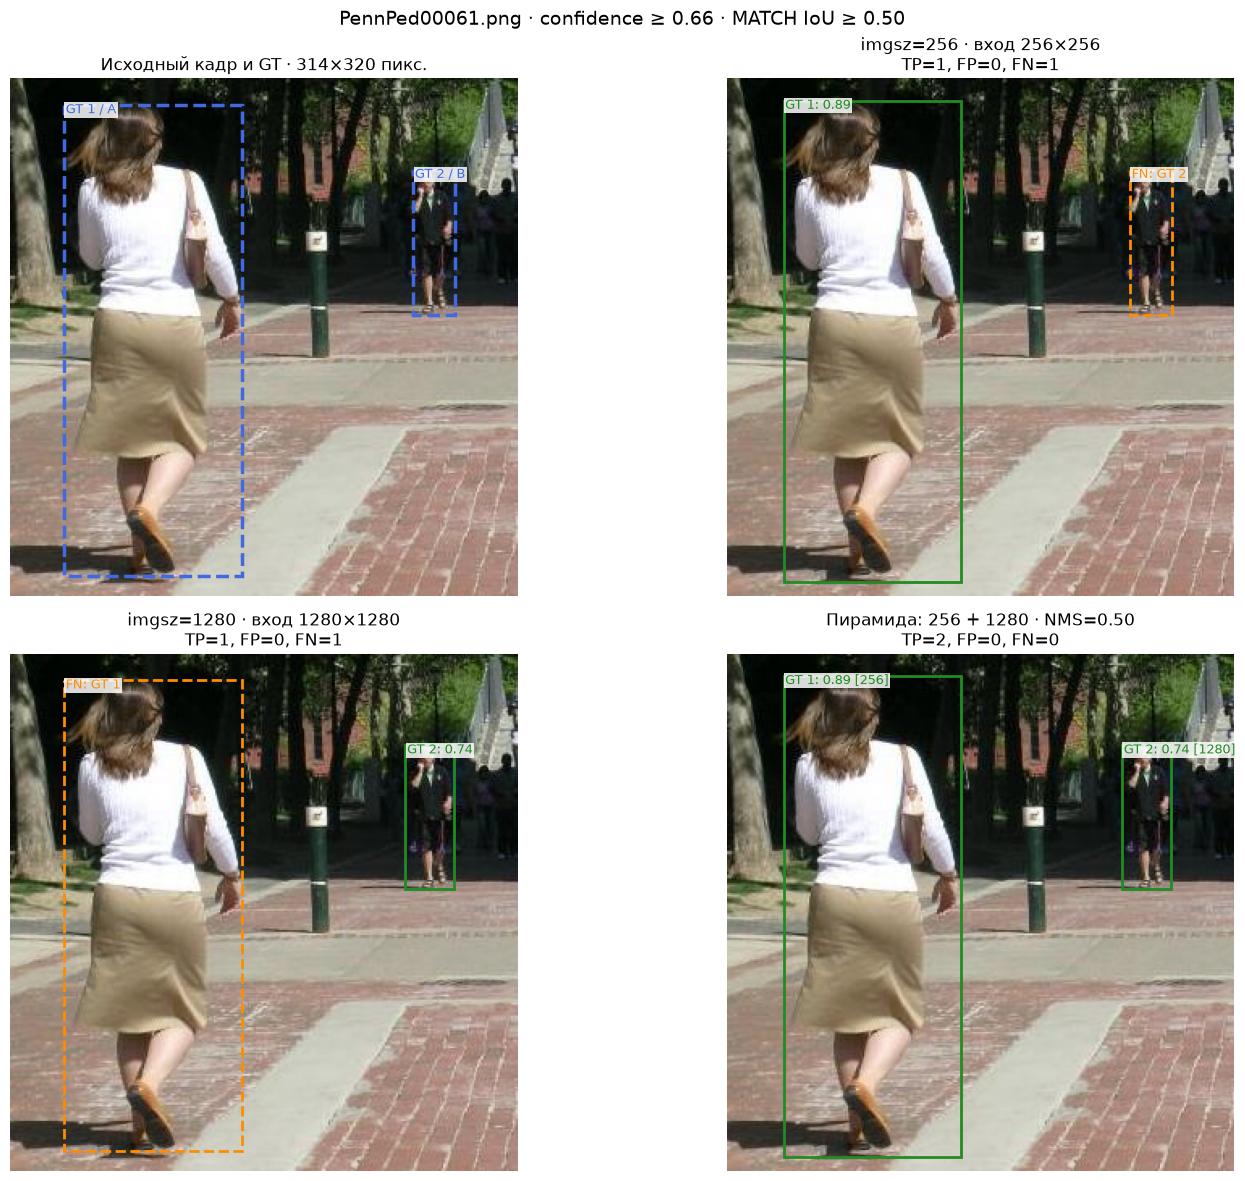

,Объект,imgsz=256: score до conf / статус,imgsz=1280: score до conf / статус,Пирамида: score / статус,Масштаб в пирамиде
0,GT 1 / A,0.895 / TP,0.231 / FN,0.895 / TP,256
1,GT 2 / B,0.591 / FN,0.739 / TP,0.739 / TP,1280


,Вариант,TP,FP,FN,Recall,Вход H×W,Пикселей на входе,"Сохранённое время, с"
0,imgsz=256,1,0,1,0.5,256×256,65536,0.068
1,imgsz=1280,1,0,1,0.5,1280×1280,1638400,0.560
2,Пирамида,2,0,0,1.0,256×256 + 1280×1280,1703936,0.627


Зелёный — TP; красный — FP; оранжевый пунктир — пропущенный GT. Число в квадратных скобках — imgsz ветви, из которой пришла рамка.
В столбцах отдельных масштабов score до conf — максимум среди сохранённых кандидатов с IoU ≥ 0.50 с этим GT, до текущего confidence. TP/FN определяется отдельно сопоставлением один-к-одному: даже подходящий кандидат не даёт TP двум объектам. В столбце пирамиды score принадлежит фактически оставленной и сопоставленной рамке. FN означает отсутствие подходящей свободной рамки после фильтрации.
После объединения подавлено рамок: 0. NMS видит только рамки и score; GT используется отдельно для оценки.
Вход H×W учитывает letterbox и stride=32; на рисунках все рамки показаны на исходном кадре. Время — сохранённая длительность вызовов predict, для пирамиды их сумма; это наблюдение одного запуска, не замер скорости модели.


In [ ]:
pyramid_prepared = prepare_pyramid()
pyramid_example = render_pyramid()

### Получите результат · 3–4 минуты

1. Начните с `Confidence=0.66`. По отдельным панелям найдите человека,
   обнаруженного только при меньшем входе, и человека, найденного только
   при большем. Сравните их score с общим порогом. **Найдите ещё два значения
   confidence**, при которых сохраняется та же противоположная ситуация.
   Укажите интервал подходящих порогов и объясните его границы.
2. Верните `Confidence=0.66`, включите обе ветви и NMS после объединения
   с порогом 0.50. **Получите TP=2, FP=0, FN=0.** Затем по очереди отключите
   каждый масштаб: какого человека потеряла пирамида? Подтвердите ответ
   номером GT и масштабом оставшейся рамки.
3. Поставьте `Confidence=0.50`, включите обе ветви и **выключите NMS после
   объединения**. Получилось ли больше найденных людей или появились повторы?
   Включите NMS обратно. Покажите удалённый дубликат и объясните, почему
   сохранилась именно другая рамка этого человека.

Под «найден» здесь понимаем TP при общем confidence и `MATCH IoU=0.50`.
Слабая или неточная рамка может существовать даже у человека, обозначенного FN.
Если на вашем устройстве пограничный результат отличается, проверьте score
в таблице и подберите общий порог по тем же правилам.

In [ ]:
pyramid_controls = make_pyramid_widget()
display(pyramid_controls)

| Опыт | Общий confidence | Ветви в объединении | NMS объединения | TP / FP / FN | Какой GT и откуда найден |
|---|---|---|---|---|---|
| Противоположные пропуски | … и …; интервал … | смотрим отдельные панели | — | … / … для каждой панели | … |
| Вместе лучше | 0.66 | 256 + 1280 | 0.50 | … | … |
| Без меньшего / без большего | 0.66 | … | 0.50 | … → … | … |
| Повторы до / после NMS | 0.50 | 256 + 1280 | выкл. → 0.50 | … → … | … |

**Обсудим:** почему увеличение разрешения не заменило пирамиду на этом
снимке? Сколько проходов сети и сколько входных пикселей потребовалось
каждому варианту? Посмотрите соответствующие строки таблицы.
Покрытие объектов может улучшиться ценой вычислений, но объединение также
способно добавить FP или неудачно подавить соседей. Этот кадр демонстрирует
механизм; для вывода о качестве на новых изображениях нужен отдельный набор.